In [3]:
## Implementing simple chatbot using langgraph
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from typing import Annotated
# REDUCERS
from langgraph.graph.message import add_messages


In [4]:
class State(TypedDict):
    messages:Annotated[list,add_messages]
    

In [1]:
import os 
from dotenv import load_dotenv
load_dotenv()
os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")



In [14]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-3.7-flash",
    temperature=1.0, 
    max_tokens=None,
    timeout=None,
    max_retries=2,
)
model.invoke("Hello how can i assist you today? ")


ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

In [13]:
from langchain_groq import ChatGroq
llm_groq = ChatGroq(model = "meta-llama/llama-prompt-guard-2-86m")
llm_groq.invoke("Hi my name is divyanshu and i like to play cricket outside")

AIMessage(content='0.00040481670293956995', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 0, 'prompt_tokens': 16, 'total_tokens': 0, 'completion_time': 0.0, 'completion_tokens_details': None, 'prompt_time': 0.0, 'prompt_tokens_details': None, 'queue_time': 0.0, 'total_time': 0.0}, 'model_name': 'meta-llama/llama-prompt-guard-2-86m', 'system_fingerprint': 'fp_a88aaa667e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a02443-afbb-7400-8b9d-e3272bee45aa-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 0, 'total_tokens': 0})

In [12]:
## We will start with creating nodes
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state["messages"])]}


In [16]:
graph = StateGraph(State)
graph.add_node("SuperBot",superbot)
graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)
graphbuilder = graph.compile()

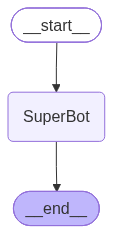

In [19]:
from IPython.display import Image,display 
display(Image(graphbuilder.get_graph().draw_mermaid_png()))

In [ ]:
# Invokation --> 
graphbuilder.invoke({"messages":"Hi,my name is Divyanshu and I like cricket"})


{'messages': [HumanMessage(content='Hi,my name is Divyanshu and I like cricket', additional_kwargs={}, response_metadata={}, id='bf3b9c3d-64fc-4238-b057-a9f36e2d3dc3'),
  AIMessage(content='0.0003972716222051531', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 0, 'prompt_tokens': 14, 'total_tokens': 0, 'completion_time': 0.0, 'completion_tokens_details': None, 'prompt_time': 0.0, 'prompt_tokens_details': None, 'queue_time': 0.0, 'total_time': 0.0}, 'model_name': 'meta-llama/llama-prompt-guard-2-86m', 'system_fingerprint': 'fp_a88aaa667e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0244e-92c7-7c11-addb-e00f2d472491-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 0, 'total_tokens': 0})]}

In [26]:
# Streaming the responses
graphbuilder.stream({"messages":"Hello my name is divyanshu"})
for event in graphbuilder.stream({"messages":"Hello my name is divyanshu"}):
    print(event)

{'SuperBot': {'messages': [AIMessage(content='0.0004044448724016547', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 0, 'prompt_tokens': 9, 'total_tokens': 0, 'completion_time': 0.0, 'completion_tokens_details': None, 'prompt_time': 0.0, 'prompt_tokens_details': None, 'queue_time': 0.0, 'total_time': 0.0}, 'model_name': 'meta-llama/llama-prompt-guard-2-86m', 'system_fingerprint': 'fp_a88aaa667e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a02459-1805-7f62-9fb5-20c6e83fb5a7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 0, 'total_tokens': 0})]}}
